# Notebook 1: Exploratory Data Analysis
## Retail Demand Forecasting — Store Sales (Favorita)

---

**Business Context**

We forecast daily grocery sales for Favorita supermarkets in Ecuador.
Accurate demand forecasting directly drives inventory decisions:

- **Overstock** — waste (critical for perishables), tied-up working capital
- **Stockout** — lost revenue, poor customer service level

This EDA follows a deliberate sequence where each step informs the next:

```
Trend Plot -> STL -> Change Point -> ADF -> ACF/PACF -> IQR -> Summary
```

**Why this order?**
- STL extracts the clean Trend component used by Change Point
- Change Point breakpoints inform whether to subset before ADF
- ADF result determines d before reading ACF/PACF for p, q, P, Q
- IQR Winsorization runs last so statistical tests are unaffected

**Scope:** Store 1, Family: GROCERY I (highest-volume, most representative)

In [1]:
# ── Dependencies ──────────────────────────────────────────────
# Uncomment to install:
# !pip install pandas numpy matplotlib seaborn statsmodels ruptures scikit-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.spines.top': False,
    'axes.spines.right': False
})
print("Imports OK")

Imports OK


In [2]:
# ── Configuration ────────────────────────────────────────────
# Windows tip: use forward slashes — Python handles both
DATA_DIR = 'C:/Users/Chloe/Desktop/Project/Store Sales Time series'
SAVE_DIR = 'C:/Users/Chloe/Desktop/Project/Store Sales Time series/outputs/EDA'

STORE_ID = 1
FAMILY   = 'GROCERY I'

import os
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'Data dir : {DATA_DIR}')
print(f'Save dir : {SAVE_DIR}')
print(f'Focus    : Store {STORE_ID} - {FAMILY}')

Data dir : C:/Users/Chloe/Desktop/Project/Store Sales Time series
Save dir : C:/Users/Chloe/Desktop/Project/Store Sales Time series/outputs/EDA
Focus    : Store 1 - GROCERY I


In [3]:
# ── Load All Files ────────────────────────────────────────────
train        = pd.read_csv(f'{DATA_DIR}/train.csv',           parse_dates=['date'])
oil          = pd.read_csv(f'{DATA_DIR}/oil.csv',             parse_dates=['date'])
holidays     = pd.read_csv(f'{DATA_DIR}/holidays_events.csv', parse_dates=['date'])
stores       = pd.read_csv(f'{DATA_DIR}/stores.csv')
transactions = pd.read_csv(f'{DATA_DIR}/transactions.csv',    parse_dates=['date'])

for name, df in [('train', train), ('oil', oil), ('holidays', holidays),
                 ('stores', stores), ('transactions', transactions)]:
    print(f"  {name:<14} {df.shape}")

print(f"\nDate range : {train['date'].min().date()} to {train['date'].max().date()}")
print(f"Stores     : {train['store_nbr'].nunique()}")
print(f"Families   : {train['family'].nunique()}")

  train          (3000888, 6)
  oil            (1218, 2)
  holidays       (350, 6)
  stores         (54, 5)
  transactions   (83488, 3)

Date range : 2013-01-01 to 2017-08-15
Stores     : 54
Families   : 33


## 1. Focus: Store 1 — GROCERY I

Narrowing to one store x family gives a clean univariate time series.
This mirrors real inventory decisions: a buyer manages one SKU-location pair at a time.

In [4]:
mask     = (train['store_nbr'] == STORE_ID) & (train['family'] == FAMILY)
df_store = train[mask].copy().sort_values('date').set_index('date')

assert not df_store.index.duplicated().any(), "Duplicate dates found!"

print(f"Rows       : {len(df_store)}")
print(f"Date range : {df_store.index.min().date()} to {df_store.index.max().date()}")
print(f"\nSales summary:")
print(df_store['sales'].describe().round(2))

Rows       : 1684
Date range : 2013-01-01 to 2017-08-15

Sales summary:
count    1684.00
mean     2223.17
std       779.29
min         0.00
25%      1873.50
50%      2283.50
75%      2649.00
max      9065.00
Name: sales, dtype: float64


## 2. Missing Value Analysis & Dealing

In [5]:
# ── Missing Value Analysis & Oil Price Merge ──────────────────
print("=== Store 1 / GROCERY I ===")
print(df_store[['sales', 'onpromotion']].isnull().sum())

print("\n=== Oil prices (before interpolation) ===")
print(f"Missing entries: {oil['dcoilwtico'].isnull().sum()} of {len(oil)} days")

# Step 1: resample to fill missing dates, Step 2: linear interpolation, Step 3: bfill for boundary NaN
oil_filled = (oil.set_index('date')['dcoilwtico']
                 .resample('D').mean()
                 .interpolate('linear')
                 .bfill())
oil_filled.name = 'oil_price'

print(f"After interpolation: {oil_filled.isnull().sum()} NaN remaining")

# Merge into df_store
df_store = df_store.join(oil_filled, how='left')

print("\n=== df_store after merge ===")
print(df_store[['sales', 'onpromotion', 'oil_price']].isnull().sum())
print(df_store[['sales', 'onpromotion', 'oil_price']].head())

=== Store 1 / GROCERY I ===
sales          0
onpromotion    0
dtype: int64

=== Oil prices (before interpolation) ===
Missing entries: 43 of 1218 days
After interpolation: 0 NaN remaining

=== df_store after merge ===
sales          0
onpromotion    0
oil_price      0
dtype: int64
             sales  onpromotion  oil_price
date                                      
2013-01-01     0.0            0  93.140000
2013-01-02  2652.0            0  93.140000
2013-01-03  2121.0            0  92.970000
2013-01-04  2056.0            0  93.120000
2013-01-05  2216.0            0  93.146667


## 3. Sales Trend Visualisation

First look at the raw series — spot trend direction, variance shifts, or visible spikes.

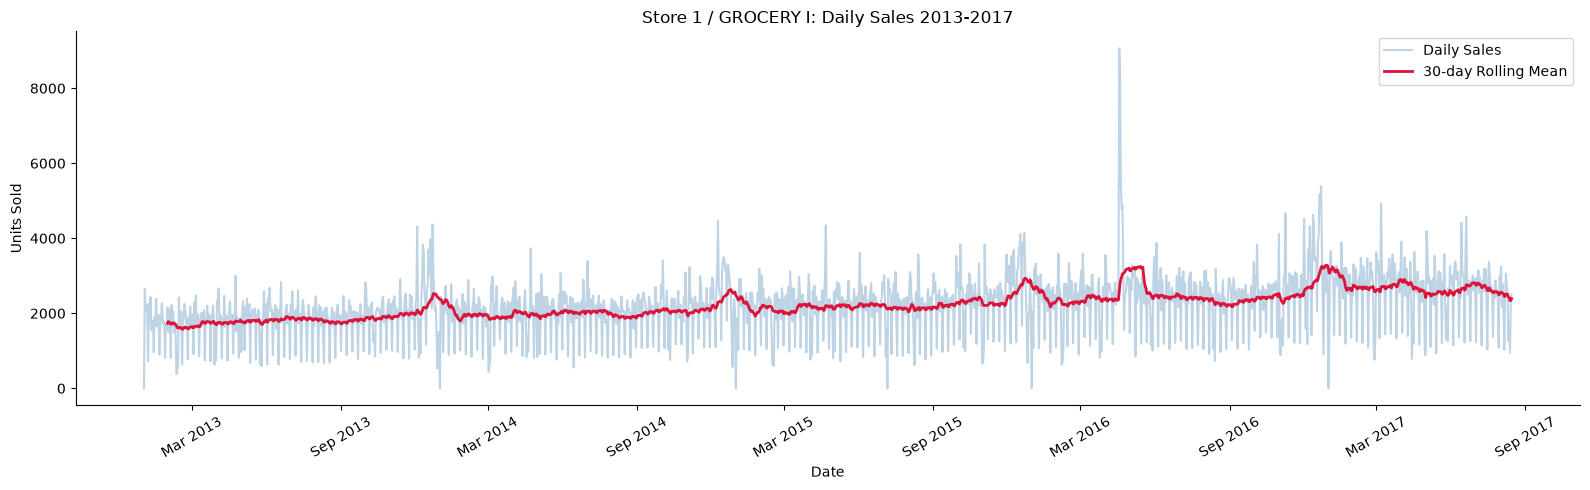

In [6]:
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df_store.index, df_store['sales'],
        alpha=0.35, color='steelblue', label='Daily Sales')
ax.plot(df_store['sales'].rolling(30).mean(),
        color='crimson', lw=2, label='30-day Rolling Mean')
ax.set(title=f'Store {STORE_ID} / {FAMILY}: Daily Sales 2013-2017',
       xlabel='Date', ylabel='Units Sold')
ax.legend()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/01_sales_trend.png', dpi=150)
plt.show()

## 4. Seasonal Decomposition — STL

STL splits the series into Trend + Seasonal + Residual.

Two outputs carried forward:
1. **Seasonal strength** — decides SARIMA vs plain ARIMA
2. **Trend component** — clean trend line fed into Change Point next

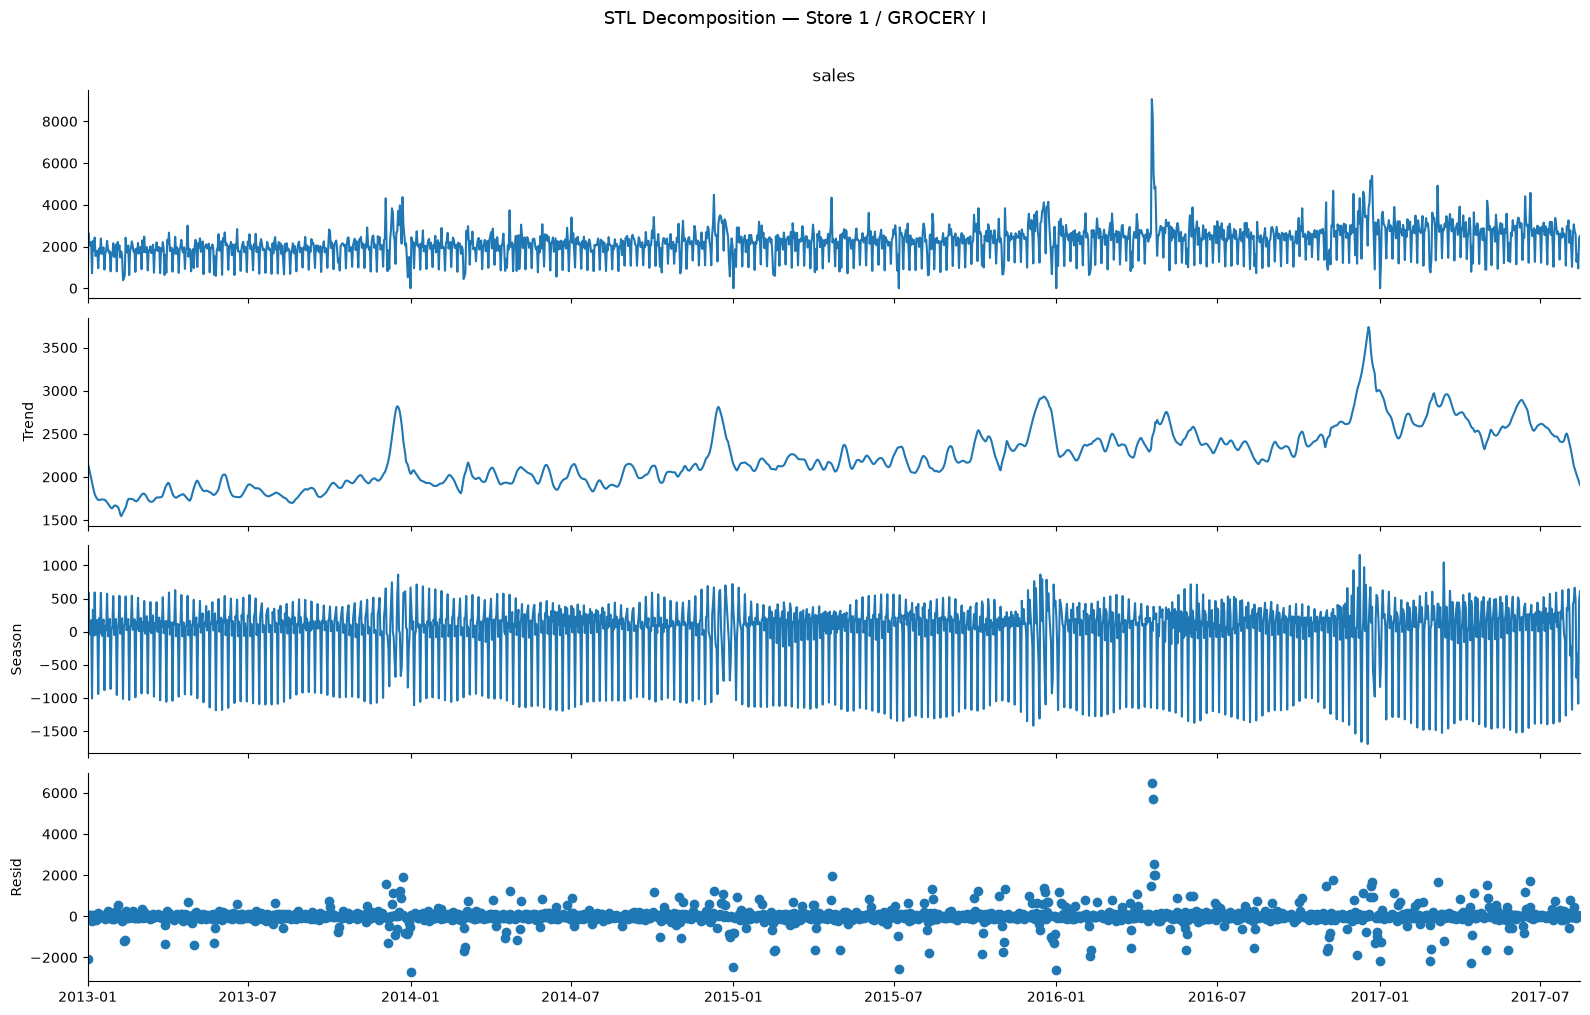

Seasonal Strength = 0.553  (0=none, 1=perfect)
Rule: > 0.6 => SARIMA preferred over plain ARIMA


In [7]:
stl = STL(df_store['sales'], period=7, robust=True)
res = stl.fit()

fig = res.plot()
fig.set_size_inches(16, 10)
fig.suptitle(f'STL Decomposition — Store {STORE_ID} / {FAMILY}', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/02_stl_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

var_resid    = np.var(res.resid)
var_seasonal = np.var(res.seasonal)
seasonal_strength = max(0.0, 1 - var_resid / (var_resid + var_seasonal))
print(f"Seasonal Strength = {seasonal_strength:.3f}  (0=none, 1=perfect)")
print("Rule: > 0.6 => SARIMA preferred over plain ARIMA")

## 5. Change Point Analysis — PELT

Detected on the **STL Trend component**, not raw sales.
This prevents weekly seasonal fluctuations from being mistaken for structural breaks.

Why before ADF:
a structural break can mislead ADF into flagging a spurious unit root.
Knowing break dates lets us decide whether to subset before running ADF.

Breakpoints detected: 0


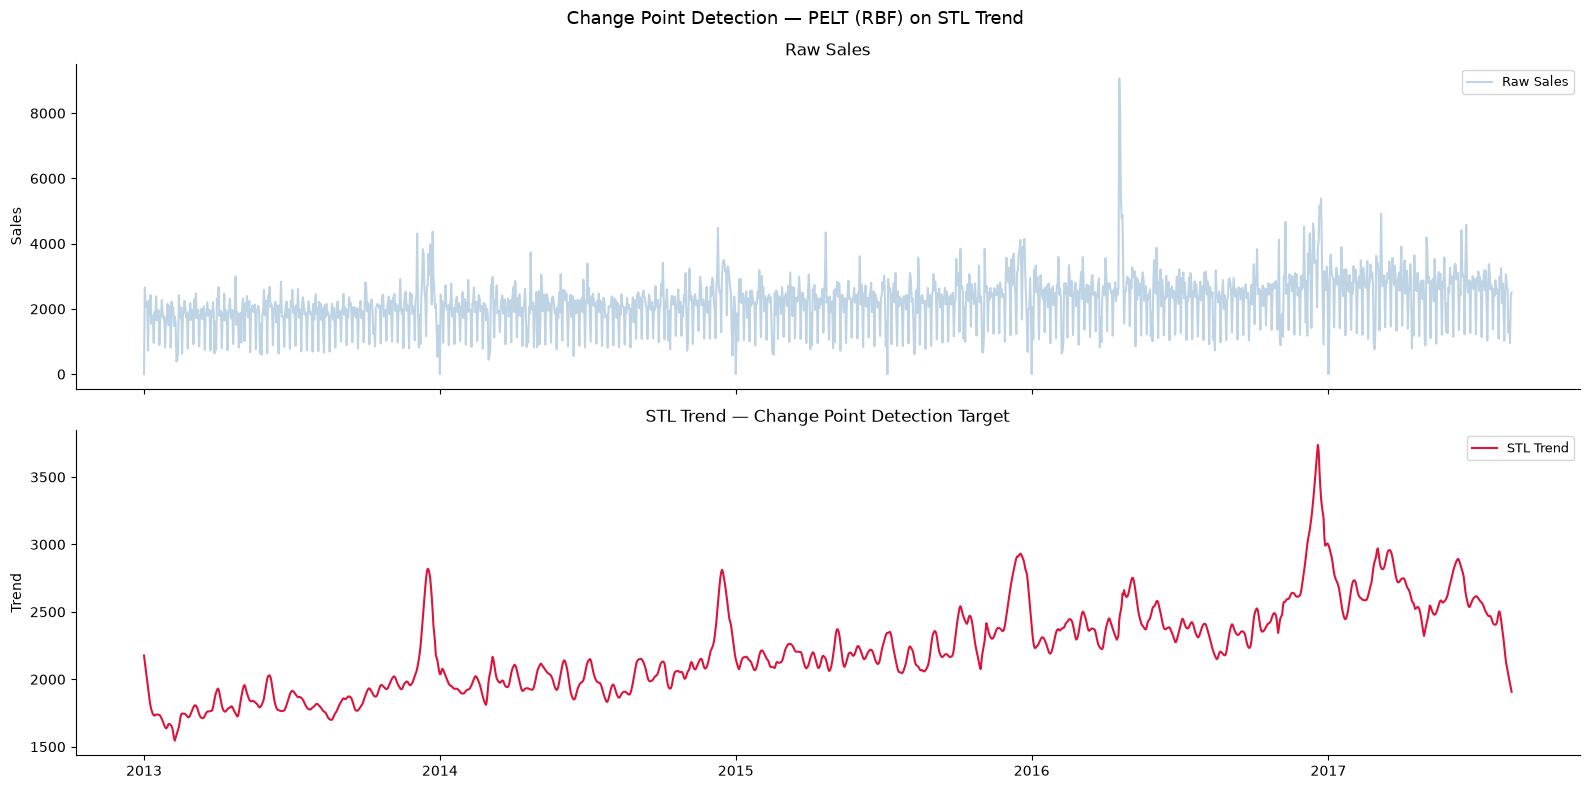

In [8]:
try:
    import ruptures as rpt
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'ruptures', '-q'])
    import ruptures as rpt

trend_signal = res.trend.values
dates        = df_store.index

algo = rpt.Pelt(model='rbf', min_size=30)
algo.fit(trend_signal)
bkps = algo.predict(pen=500)

bp_dates = [dates[i - 1] for i in bkps if i < len(dates)]
print(f"Breakpoints detected: {len(bp_dates)}")
for d in bp_dates:
    print(f"  {d.date()}")

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
axes[0].plot(dates, df_store['sales'], alpha=0.35, color='steelblue', label='Raw Sales')
axes[0].set(title='Raw Sales', ylabel='Sales')
axes[1].plot(dates, trend_signal, color='crimson', lw=1.5, label='STL Trend')
axes[1].set(title='STL Trend — Change Point Detection Target', ylabel='Trend')

for ax in axes:
    for i, d in enumerate(bp_dates):
        ax.axvline(x=d, color='black', linestyle='--', alpha=0.7,
                   label='Breakpoint' if i == 0 else '')
    ax.legend(fontsize=9)

plt.suptitle('Change Point Detection — PELT (RBF) on STL Trend', fontsize=13)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/03_change_points.png', dpi=150)
plt.show()

if len(bp_dates) > 0:
    print(f"\nConsider subsetting from {bp_dates[-1].date()} onwards before ADF")

In [9]:
# ── Optional: subset post last breakpoint ────────────────────
# Set SUBSET_FROM to a date string to truncate, or None for full series.

SUBSET_FROM = None   # e.g., '2015-04-01'

if SUBSET_FROM:
    df_model = df_store[df_store.index >= SUBSET_FROM].copy()
    print(f"Subset: {df_model.index.min().date()} to {df_model.index.max().date()} [{len(df_model)} rows]")
else:
    df_model = df_store.copy()
    print("Using full series for ADF / ACF/PACF")

Using full series for ADF / ACF/PACF


## 6. Stationarity — Augmented Dickey-Fuller Test

Run after resolving change points, on the (possibly subsetted) series.

**H0:** the series has a unit root (non-stationary)

| p-value | Conclusion | Action |
|---------|-----------|--------|
| < 0.05  | Reject H0 — stationary | d = 0 |
| >= 0.05 | Fail to reject — non-stationary | d = 1, re-test on differenced series |

In [10]:
def adf_test(series, name='Series'):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f"{'─'*52}")
    print(f" ADF Test — {name}")
    print(f"  ADF Statistic : {result[0]:>10.4f}")
    print(f"  p-value       : {result[1]:>10.4f}")
    print(f"  Lags used     : {result[2]}")
    for k, v in result[4].items():
        print(f"  Critical {k:>4} : {v:>10.4f}")
    label = "STATIONARY (d=0)" if result[1] < 0.05 else "NON-STATIONARY (d=1 needed)"
    print(f"  --> {label}")
    return result[1]

p_orig = adf_test(df_model['sales'], 'Original Sales')

if p_orig >= 0.05:
    print()
    adf_test(df_model['sales'].diff().dropna(), 'First Difference')

────────────────────────────────────────────────────
 ADF Test — Original Sales
  ADF Statistic :    -4.1504
  p-value       :     0.0008
  Lags used     : 24
  Critical   1% :    -3.4343
  Critical   5% :    -2.8633
  Critical  10% :    -2.5677
  --> STATIONARY (d=0)


## 7. Outlier Detection — IQR Method

Runs after all statistical tests so ADF and ACF/PACF reflect true data distribution.
Outliers are **Winsorized (capped)**, not removed — the time index stays intact.

```
IQR         = Q3 - Q1
Lower bound = Q1 - 1.5 * IQR
Upper bound = Q3 + 1.5 * IQR
```

Q1            = 1873.50
Q3            = 2649.00
IQR           = 775.50
Lower bound   = 710.25
Upper bound   = 3812.25
Outliers      = 72 (4.3% of series)


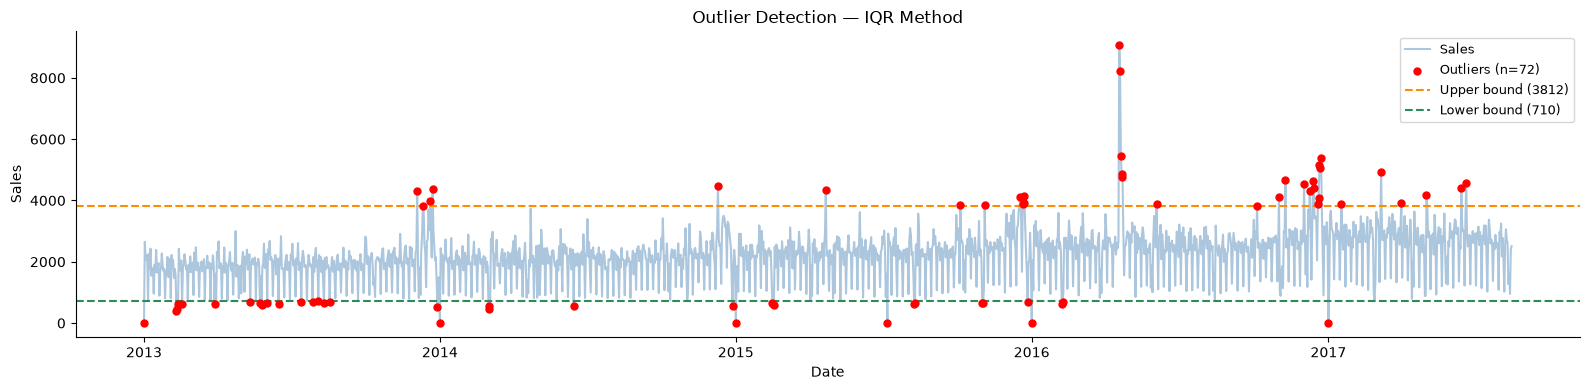

In [11]:
# ── Step 1: IQR Detection ─────────────────────────────────────
sales = df_model['sales']

Q1  = sales.quantile(0.25)
Q3  = sales.quantile(0.75)
IQR = Q3 - Q1
lb  = Q1 - 1.5 * IQR
ub  = Q3 + 1.5 * IQR

outliers = sales[(sales < lb) | (sales > ub)]

print(f"Q1            = {Q1:.2f}")
print(f"Q3            = {Q3:.2f}")
print(f"IQR           = {IQR:.2f}")
print(f"Lower bound   = {lb:.2f}")
print(f"Upper bound   = {ub:.2f}")
print(f"Outliers      = {len(outliers)} ({len(outliers)/len(sales)*100:.1f}% of series)")

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(sales, alpha=0.45, color='steelblue', label='Sales')
ax.scatter(outliers.index, outliers.values,
           color='red', zorder=5, s=25, label=f'Outliers (n={len(outliers)})')
ax.axhline(ub, color='darkorange', linestyle='--', lw=1.5,
           label=f'Upper bound ({ub:.0f})')
ax.axhline(lb, color='seagreen', linestyle='--', lw=1.5,
           label=f'Lower bound ({lb:.0f})')
ax.set(title='Outlier Detection — IQR Method', xlabel='Date', ylabel='Sales')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/05_outliers_iqr.png', dpi=150)
plt.show()

In [12]:
# ── Step 2: Classify Outliers ─────────────────────────────────
outlier_dates     = outliers.index
holidays_national = holidays[holidays['locale'] == 'National']

# All holiday overlaps
overlap = holidays_national[holidays_national['date'].isin(outlier_dates)].copy()

# Check type distribution
print("=== Outlier breakdown by holiday type ===")
print(overlap['type'].value_counts())
print()

# Separate Event into recurring vs one-time
ONE_TIME_KEYWORDS = ['Terremoto', 'Mundial', 'Inauguracion']

one_time_mask = (
    (overlap['type'] == 'Event') &
    (overlap['description'].str.contains('|'.join(ONE_TIME_KEYWORDS), na=False))
)

event_one_time  = overlap[one_time_mask]
event_recurring = overlap[(overlap['type'] == 'Event') & ~one_time_mask]
holiday_overlap = overlap[overlap['type'] != 'Event']

holiday_outlier_dates = pd.DatetimeIndex(holiday_overlap['date'])
event_outlier_dates   = pd.DatetimeIndex(event_one_time['date'])
non_holiday_dates     = outlier_dates[
    ~outlier_dates.isin(holiday_outlier_dates) &
    ~outlier_dates.isin(event_outlier_dates) &
    ~outlier_dates.isin(pd.DatetimeIndex(event_recurring['date']))
]

print(f"Total outliers          : {len(outliers)}")
print(f"  Holiday type          : {len(holiday_outlier_dates)}  -> keep as-is")
print(f"  Event (one-time)      : {len(event_outlier_dates)}  -> interpolate")
print(f"  Event (recurring)     : {len(event_recurring)}  -> keep as-is")
print(f"  Non-holiday           : {len(non_holiday_dates)}  -> Winsorize")
print()
print("One-time events (interpolate):")
print(event_one_time[['date', 'description']].to_string(index=False))
print()
print("Recurring events (keep):")
print(event_recurring[['date', 'description']].to_string(index=False))

=== Outlier breakdown by holiday type ===
type
Holiday       14
Event          7
Additional     7
Name: count, dtype: int64

Total outliers          : 72
  Holiday type          : 21  -> keep as-is
  Event (one-time)      : 6  -> interpolate
  Event (recurring)     : 1  -> keep as-is
  Non-holiday           : 44  -> Winsorize

One-time events (interpolate):
      date                             description
2014-06-15 Mundial de futbol Brasil: Ecuador-Suiza
2016-04-18                      Terremoto Manabi+2
2016-04-19                      Terremoto Manabi+3
2016-04-20                      Terremoto Manabi+4
2016-04-21                      Terremoto Manabi+5
2016-04-22                      Terremoto Manabi+6

Recurring events (keep):
      date     description
2013-05-12 Dia de la Madre


In [13]:
# ── Step 3: Apply Treatment ───────────────────────────────────
df_model['sales_clean'] = df_model['sales'].copy()

# Treatment 1: Winsorize non-holiday, non-event outliers
mask = (
    ~df_model.index.isin(holiday_outlier_dates) &
    ~df_model.index.isin(event_outlier_dates) &
    ~df_model.index.isin(pd.DatetimeIndex(event_recurring['date']))
)
df_model.loc[mask, 'sales_clean'] = df_model.loc[mask, 'sales'].clip(lower=lb, upper=ub)

# Treatment 2: Interpolate one-time events
df_model.loc[event_outlier_dates, 'sales_clean'] = np.nan
df_model['sales_clean'] = df_model['sales_clean'].interpolate('linear')

print("Treatment applied:")
print(f"  {len(holiday_outlier_dates)} holiday outliers        : kept as-is")
print(f"  {len(event_recurring)} recurring event outliers : kept as-is (Dia de la Madre)")
print(f"  {len(event_outlier_dates)} one-time event outliers : interpolated")
print(f"  {len(non_holiday_dates)} non-holiday outliers    : Winsorized")
print()
print("One-time events interpolated:")
for d in event_outlier_dates:
    print(f"  {d.date()} : {df_model.loc[d, 'sales']:.0f} -> {df_model.loc[d, 'sales_clean']:.0f}")

Treatment applied:
  21 holiday outliers        : kept as-is
  1 recurring event outliers : kept as-is (Dia de la Madre)
  6 one-time event outliers : interpolated
  44 non-holiday outliers    : Winsorized

One-time events interpolated:
  2014-06-15 : 556 -> 2328
  2016-04-18 : 9065 -> 2714
  2016-04-19 : 8221 -> 2779
  2016-04-20 : 5438 -> 2844
  2016-04-21 : 4768 -> 2909
  2016-04-22 : 4871 -> 2974


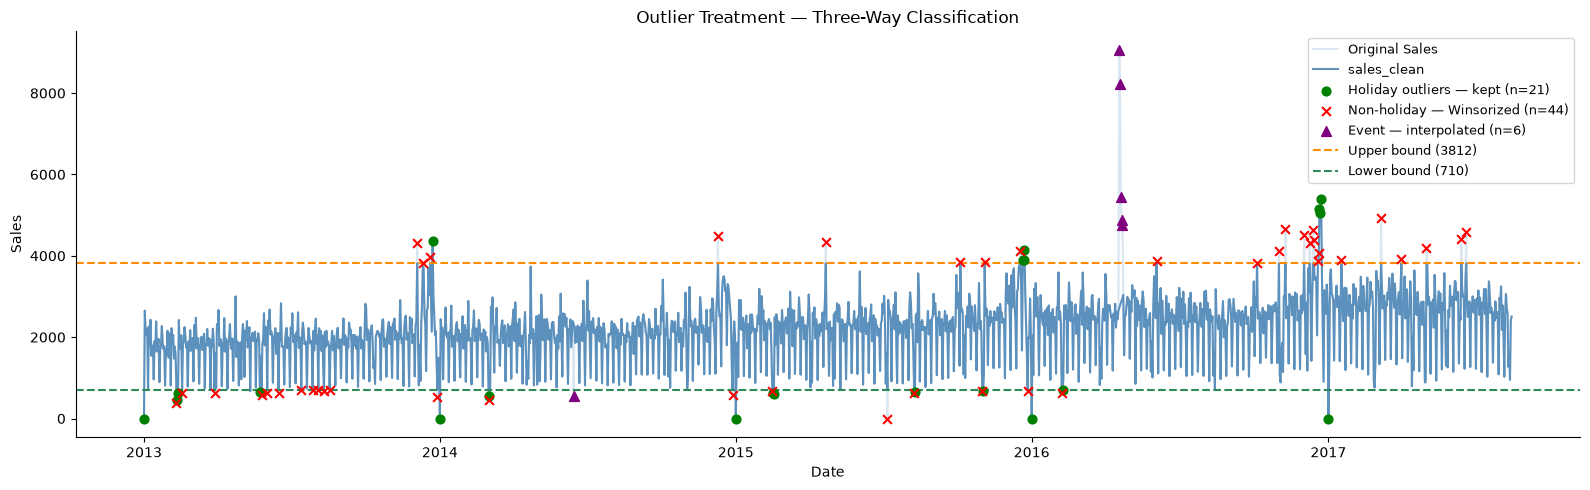

In [14]:
# ── Step 4: Visualise ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(df_model.index, df_model['sales'],
        alpha=0.2, color='steelblue', label='Original Sales')
ax.plot(df_model.index, df_model['sales_clean'],
        alpha=0.85, color='steelblue', label='sales_clean')

ax.scatter(holiday_outlier_dates,
           df_model.loc[holiday_outlier_dates, 'sales'],
           color='green', zorder=5, s=40,
           label=f'Holiday outliers — kept (n={len(holiday_outlier_dates)})')

ax.scatter(non_holiday_dates,
           df_model.loc[non_holiday_dates, 'sales'],
           color='red', zorder=5, s=40, marker='x',
           label=f'Non-holiday — Winsorized (n={len(non_holiday_dates)})')

ax.scatter(event_outlier_dates,
           df_model.loc[event_outlier_dates, 'sales'],
           color='purple', zorder=5, s=50, marker='^',
           label=f'Event — interpolated (n={len(event_outlier_dates)})')

ax.axhline(ub, color='darkorange', linestyle='--', lw=1.5,
           label=f'Upper bound ({ub:.0f})')
ax.axhline(lb, color='seagreen', linestyle='--', lw=1.5,
           label=f'Lower bound ({lb:.0f})')

ax.set(title='Outlier Treatment — Three-Way Classification',
       xlabel='Date', ylabel='Sales')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/05b_outlier_treatment.png', dpi=150)
plt.show()

## 8. ACF / PACF — Read Model Orders

| Plot | What to look for | Order to set |
|------|----------------|-------------|
| PACF | Cuts off after lag k | p = k |
| ACF  | Cuts off after lag k | q = k |
| PACF | Spike at lag 7, 14... | P >= 1 |
| ACF  | Spike at lag 7, 14... | Q >= 1 |

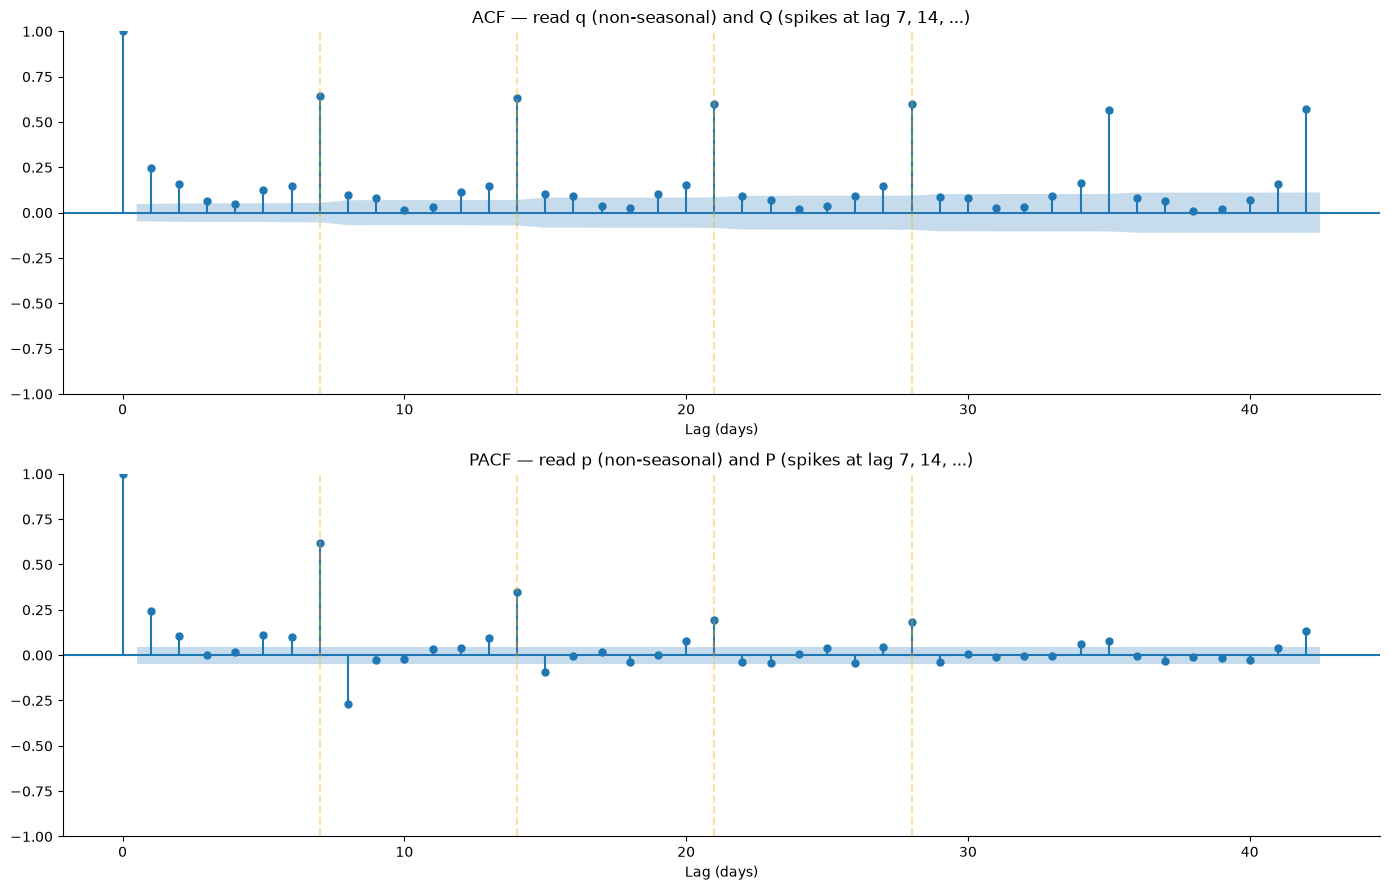

In [15]:
series_plot = df_model['sales_clean'].diff().dropna() if p_orig >= 0.05 else df_model['sales_clean']

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

plot_acf(series_plot, lags=42, alpha=0.05, ax=axes[0])
axes[0].set_title('ACF — read q (non-seasonal) and Q (spikes at lag 7, 14, ...)')
axes[0].set_xlabel('Lag (days)')

plot_pacf(series_plot, lags=42, alpha=0.05, method='ywm', ax=axes[1])
axes[1].set_title('PACF — read p (non-seasonal) and P (spikes at lag 7, 14, ...)')
axes[1].set_xlabel('Lag (days)')

for ax in axes:
    for lag in [7, 14, 21, 28]:
        ax.axvline(x=lag, color='orange', linestyle='--', alpha=0.35)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/04_acf_pacf.png', dpi=150)
plt.show()

## 9. EDA Summary — Model Selection Decision

In [16]:
summary = pd.DataFrame({
    'Step': ['Trend', 'Seasonal Strength', 'Seasonal Period',
             'Change Points', 'Stationarity (ADF)', 'Outliers'],
    'Finding': [
        'Slight upward trend, higher variance in later years',
        f'{seasonal_strength:.2f}',
        's = 7',
        f'{len(bp_dates)} breakpoints detected',
        'stationary (d=0)' if p_orig < 0.05 else 'non-stationary -> d=1',
        f'{len(outliers)-len(overlap)} non-holiday outliers Winsorized'
    ],
    'Model Impact': [
        'Trend captured by d in SARIMA',
        'Using SARIMA — ACF/PACF lag 7 peaks confirm weekly seasonality',
        'seasonal_order s=7',
        'Subsetted post-break' if SUBSET_FROM else 'Full series used',
        'd=0' if p_orig < 0.05 else 'd=1',
        'Use sales_clean as modeling target'
    ]
})
print(summary.to_string(index=False))
df_model[['sales_clean', 'onpromotion', 'oil_price']].to_csv(
    f'{SAVE_DIR}/store1_grocery1_clean.csv')
print("\nClean data saved -> outputs/EDA/store1_grocery1_clean.csv")
print("Next: Notebook 2 — SARIMA / SARIMAX Modeling")

              Step                                             Finding                                                   Model Impact
             Trend Slight upward trend, higher variance in later years                                  Trend captured by d in SARIMA
 Seasonal Strength                                                0.55 Using SARIMA — ACF/PACF lag 7 peaks confirm weekly seasonality
   Seasonal Period                                               s = 7                                             seasonal_order s=7
     Change Points                              0 breakpoints detected                                               Full series used
Stationarity (ADF)                                    stationary (d=0)                                                            d=0
          Outliers                  44 non-holiday outliers Winsorized                             Use sales_clean as modeling target

Clean data saved -> outputs/EDA/store1_grocery1_clean.csv
Nex